# 02 — Detect and Cut
Set `INPUT_VIDEO` to your MP4 path and **Run All**.

- Params are loaded automatically from `params/` (same folder as this notebook)
- Outputs land in `<match_folder>/outputs/`
- Final video is named `<video name> edited.mp4`
- Temporary segment files are deleted after the final video is assembled

In [11]:
# ── Only thing to edit ───────────────────────────────────────────────────────
INPUT_VIDEO = r"Raja vs Wijemanne\Raja vs Wijemanne.mp4"
# Can be relative (from RunDirectory/) or an absolute path
# ─────────────────────────────────────────────────────────────────────────────

# Tuning knobs — leave as-is unless detections look wrong
K_MAD         = 6.0   # threshold sensitivity: lower = more detections
MIN_GAP_MS    = 250   # min ms between two detections
GROUP_GAP_S   = 5.0   # gap that splits detections into separate groups/rallies
PRE_BUFFER_S  = 1.0   # seconds to keep before the first hit in any segment
POST_SINGLE_S = 1.0   # extra seconds after an isolated single detection
POST_GROUP_S  = 0.5   # extra seconds after the last hit in a rally group

In [12]:
import numpy as np
from pathlib import Path
from scipy.signal import correlate2d, find_peaks, butter, sosfiltfilt
import matplotlib.pyplot as plt
import librosa, librosa.display
import subprocess, os, shutil, tempfile

%matplotlib inline

# ── Derive all paths from INPUT_VIDEO ────────────────────────────────────────
video_path = Path(INPUT_VIDEO).resolve()
match_dir  = video_path.parent
out_dir    = match_dir / "outputs"
params_dir = Path.cwd() / "params"        # always RunDirectory/params/
final_name = video_path.stem + " edited.mp4"
final_out  = out_dir / final_name

out_dir.mkdir(parents=True, exist_ok=True)

print(f"Video  : {video_path}")
print(f"Params : {params_dir}")
print(f"Output : {final_out}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def bandpass(audio, sr, lo=1000.0, hi=8000.0, order=4):
    nyq = 0.5 * sr
    sos = butter(order, [lo/nyq, hi/nyq], btype="bandpass", output="sos")
    return sosfiltfilt(sos, audio).astype(np.float32)

def ncc(template, spec):
    t = (template - template.mean()) / (template.std() + 1e-8)
    s = (spec     - spec.mean())     / (spec.std()     + 1e-8)
    return correlate2d(s, t, mode="valid")

def detect(response, sr, hop, min_gap_ms, k_mad, offset_ms):
    r = np.asarray(response, dtype=np.float32).ravel()
    med = np.median(r)
    thr = med + k_mad * 1.4826 * (np.median(np.abs(r - med)) + 1e-12)
    gap = int(round(min_gap_ms/1000 * sr / hop))
    idx, props = find_peaks(r, height=thr, distance=max(1, gap))
    return idx * (hop/sr) + offset_ms/1000, props["peak_heights"], thr

def save_labels(times, path, dur_ms=50):
    with open(path, "w") as f:
        for t in times:
            f.write(f"{t:.6f}\t{t+dur_ms/1000:.6f}\tthwack\n")
    print(f"Labels -> {path}  ({len(times)} detections)")

def find_ffmpeg():
    try:
        import imageio_ffmpeg; return imageio_ffmpeg.get_ffmpeg_exe()
    except Exception: pass
    ff = shutil.which("ffmpeg")
    if ff: return ff
    raise RuntimeError("ffmpeg not found. Run: pip install imageio-ffmpeg")

Video  : C:\ThatFamily Dropbox\Sorin Jayaweera\allSaves\mudd\junior\Digital Signal Processing\code\TENNIS\RunDirectory\Raja vs Wijemanne\Raja vs Wijemanne.mp4
Params : c:\ThatFamily Dropbox\Sorin Jayaweera\allSaves\mudd\junior\Digital Signal Processing\code\TENNIS\RunDirectory\params
Output : C:\ThatFamily Dropbox\Sorin Jayaweera\allSaves\mudd\junior\Digital Signal Processing\code\TENNIS\RunDirectory\Raja vs Wijemanne\outputs\Raja vs Wijemanne edited.mp4


## Load params

In [13]:
template   = np.load(params_dir / "template.npy")
sr         = int(np.load(params_dir / "sr.npy")[0])
hop_length = int(np.load(params_dir / "hop_length.npy")[0])
n_fft      = int(np.load(params_dir / "n_fft.npy")[0])
pre_ms     = float(np.load(params_dir / "pre_ms.npy")[0])
print(f"Template: {template.shape}  sr={sr}  hop={hop_length}")

Template: (1025, 10)  sr=44100  hop=512


## Extract audio

In [14]:
ffmpeg = find_ffmpeg()
tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False); tmp.close()
print(f"Extracting audio ...")
res = subprocess.run(
    [ffmpeg, "-y", "-loglevel", "error",
     "-i", str(video_path), "-vn", "-ac", "1", "-ar", str(sr),
     "-acodec", "pcm_s16le", "-f", "wav", tmp.name],
    capture_output=True)
if res.returncode != 0:
    os.unlink(tmp.name)
    raise RuntimeError(res.stdout.decode(errors="replace") + res.stderr.decode(errors="replace"))

audio_raw, sr_check = librosa.load(tmp.name, sr=None)
os.unlink(tmp.name)
assert sr_check == sr, f"Video sr {sr_check} != template sr {sr}"

audio_bp     = bandpass(audio_raw, sr)
duration_min = len(audio_raw) / sr / 60
print(f"Duration: {duration_min:.1f} min  ({sr} Hz)")

Extracting audio ...
Duration: 94.8 min  (44100 Hz)


## Run matched filter

Computing STFT ...
Running NCC on 489689 frames ...
Done.


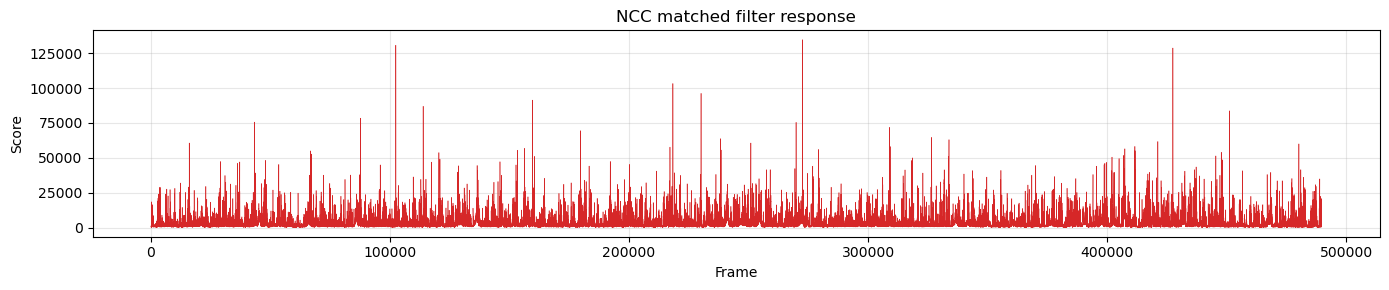

In [15]:
print("Computing STFT ...")
mag = np.abs(librosa.stft(audio_bp, n_fft=n_fft, hop_length=hop_length))
print(f"Running NCC on {mag.shape[1]} frames ...")
corr = ncc(template, mag)
print("Done.")

plt.figure(figsize=(14,3))
plt.plot(corr[0], lw=0.4, color="#d62728")
plt.title("NCC matched filter response"); plt.xlabel("Frame"); plt.ylabel("Score")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Detect hits

Detections: 2372  |  threshold: 10354.467  |  rate: 25.0/min
Labels -> C:\ThatFamily Dropbox\Sorin Jayaweera\allSaves\mudd\junior\Digital Signal Processing\code\TENNIS\RunDirectory\Raja vs Wijemanne\outputs\detections.txt  (2372 detections)


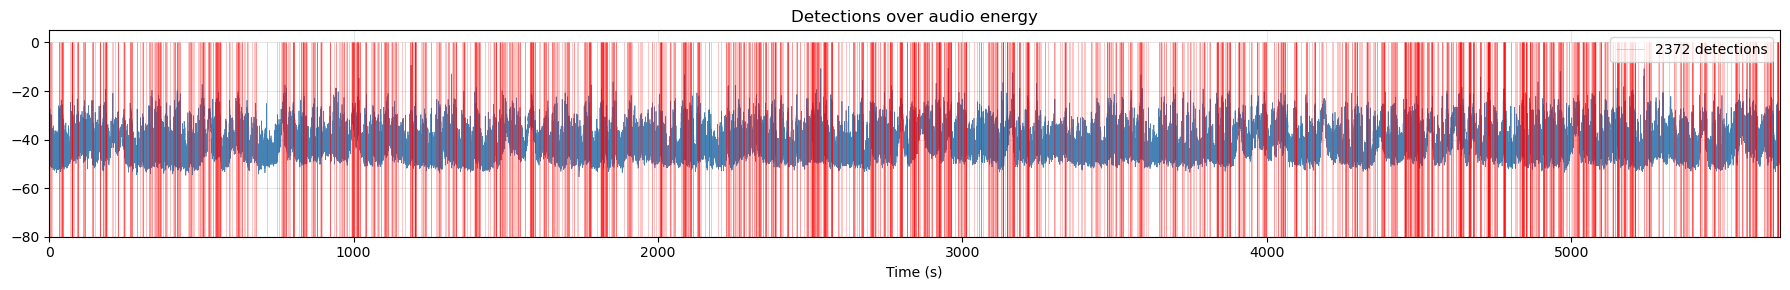

In [16]:
times, scores, thr = detect(corr[0], sr, hop_length, MIN_GAP_MS, K_MAD, pre_ms)
video_dur = len(audio_raw) / sr

print(f"Detections: {len(times)}  |  threshold: {thr:.3f}  |  rate: {len(times)/duration_min:.1f}/min")
save_labels(times, out_dir / "detections.txt")

rms      = librosa.feature.rms(y=audio_raw, frame_length=n_fft, hop_length=hop_length)[0]
t_frames = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
fig, ax  = plt.subplots(figsize=(18,3))
ax.plot(t_frames, 20*np.log10(rms+1e-6), color="steelblue", lw=0.5)
ax.vlines(times, -80, 0, colors="red", lw=0.4, alpha=0.4, label=f"{len(times)} detections")
ax.set_xlim(0, t_frames[-1]); ax.set_ylim(-80,5)
ax.set_xlabel("Time (s)"); ax.legend(loc="upper right"); ax.grid(alpha=0.3)
ax.set_title("Detections over audio energy"); plt.tight_layout(); plt.show()

## Group into rally segments

Segments: 309  |  total: 46.7 min  (49% of original)


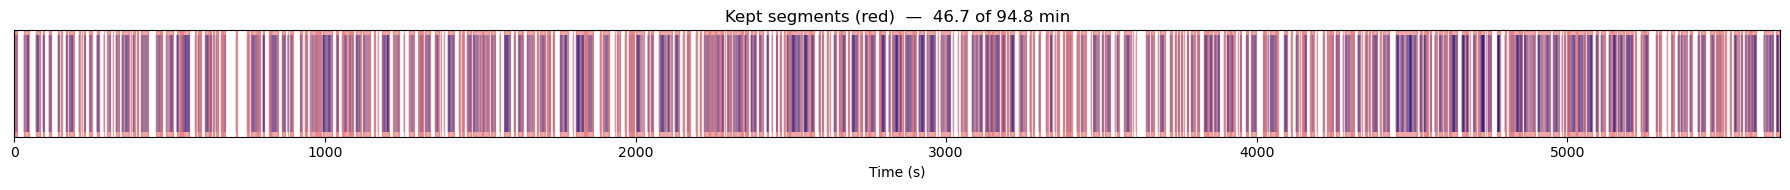

In [17]:
sorted_t = np.sort(times)
groups, cur = [], [sorted_t[0]]
for t in sorted_t[1:]:
    if t - cur[-1] <= GROUP_GAP_S: cur.append(t)
    else: groups.append(cur); cur = [t]
groups.append(cur)

segs = []
for g in groups:
    start = max(0.0, g[0] - PRE_BUFFER_S)
    end   = min(video_dur, g[-1] + (POST_SINGLE_S if len(g)==1 else POST_GROUP_S))
    segs.append((start, end))

# Merge overlapping
segs.sort(); merged = [list(segs[0])]
for s,e in segs[1:]:
    if s <= merged[-1][1]: merged[-1][1] = max(merged[-1][1], e)
    else: merged.append([s, e])
segs = [tuple(x) for x in merged]

total_s = sum(e-s for s,e in segs)
print(f"Segments: {len(segs)}  |  total: {total_s/60:.1f} min  ({total_s/video_dur*100:.0f}% of original)")

fig, ax = plt.subplots(figsize=(18,2))
for s,e in segs: ax.axvspan(s, e, alpha=0.4, color="#d62728")
ax.vlines(sorted_t, 0, 1, colors="navy", lw=0.3, alpha=0.4)
ax.set_xlim(0, video_dur); ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title(f"Kept segments (red)  —  {total_s/60:.1f} of {duration_min:.1f} min")
plt.tight_layout(); plt.show()

## Cut, concatenate, and clean up
Segments are cut with `ffmpeg -c copy` (no re-encode, fast).
Individual clips are deleted once the final video is assembled.

In [18]:
seg_dir = out_dir / "_segments_tmp"
seg_dir.mkdir(exist_ok=True)

seg_paths = []
print(f"Cutting {len(segs)} segments ...")
for i, (start, end) in enumerate(segs, 1):
    p = seg_dir / f"seg_{i:04d}.mp4"
    seg_paths.append(p)
    res = subprocess.run(
        [ffmpeg, "-y", "-loglevel", "error",
         "-ss", f"{start:.3f}", "-to", f"{end:.3f}",
         "-i", str(video_path), "-c", "copy", str(p)],
        capture_output=True)
    if res.returncode != 0:
        print(f"  seg {i:04d} FAILED: {res.stderr.decode(errors='replace')[:150]}")
    else:
        print(f"  seg {i:04d}  {start:7.1f}s -> {end:7.1f}s  ({end-start:.0f}s)  "
              f"{p.stat().st_size/1e6:.1f} MB")

# Concatenate
concat_txt = seg_dir / "list.txt"
with open(concat_txt, "w") as f:
    for p in seg_paths:
        if p.exists(): f.write(f"file '{p.resolve()}'\n")

print(f"\nConcatenating into: {final_out.name} ...")
res = subprocess.run(
    [ffmpeg, "-y", "-loglevel", "error",
     "-f", "concat", "-safe", "0",
     "-i", str(concat_txt), "-c", "copy", str(final_out)],
    capture_output=True)

if res.returncode != 0:
    print("Concat failed:", res.stderr.decode(errors="replace")[:400])
else:
    # Clean up temp segments
    shutil.rmtree(seg_dir)
    mb = final_out.stat().st_size / 1e6
    print(f"\nDone !  {final_out.name}")
    print(f"Size:  {mb:.1f} MB  ({total_s/60:.1f} min highlights from {duration_min:.1f} min)")
    print(f"Path:  {final_out}")

Cutting 309 segments ...
  seg 0001      1.7s ->     8.7s  (7s)  1.3 MB
  seg 0002     30.8s ->    45.5s  (15s)  2.7 MB
  seg 0003     68.8s ->    83.2s  (14s)  2.6 MB
  seg 0004     91.4s ->    96.1s  (5s)  0.9 MB
  seg 0005    110.0s ->   118.3s  (8s)  1.7 MB
  seg 0006    139.3s ->   144.3s  (5s)  1.2 MB
  seg 0007    150.3s ->   152.3s  (2s)  0.6 MB
  seg 0008    166.2s ->   169.2s  (3s)  0.7 MB
  seg 0009    175.6s ->   190.6s  (15s)  2.7 MB
  seg 0010    206.4s ->   210.0s  (4s)  0.7 MB
  seg 0011    216.9s ->   218.9s  (2s)  0.5 MB
  seg 0012    224.6s ->   227.5s  (3s)  0.6 MB
  seg 0013    241.7s ->   248.4s  (7s)  1.3 MB
  seg 0014    264.6s ->   272.7s  (8s)  1.5 MB
  seg 0015    288.1s ->   289.9s  (2s)  0.5 MB
  seg 0016    298.9s ->   308.9s  (10s)  1.9 MB
  seg 0017    315.9s ->   317.9s  (2s)  0.5 MB
  seg 0018    326.0s ->   338.3s  (12s)  2.4 MB
  seg 0019    344.9s ->   367.8s  (23s)  4.1 MB
  seg 0020    374.1s ->   376.1s  (2s)  0.5 MB
  seg 0021    380.2s ->   386